In [1]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [2]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
x_train = np.load('Train_3D_128_FOV_norm_data.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))
vol_shape = x_train.shape[1:]
print('train vol_shape:', vol_shape)
print('train shape:', x_train.shape)

train vol_shape: (128, 128, 128)
train shape: (57, 128, 128, 128)


In [5]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
inshape = (*x_train.shape[1:], unet_input_features)

# configure unet features 
# nb_features = [
#     [16, 32, 32, 32],
#     [32, 32, 32, 32, 32, 16, 16]
# ]

nb_features = [
    [32, 64, 64, 64],
    [64, 64, 64, 64, 32, 16, 16]
]

# nb_features = [
#     [64, 128, 256, 512],
#     [512, 512, 256, 128, 64, 32, 16]
# ]
model3D = vxm.networks.VxmDense(vol_shape, nb_features, int_steps=0)
model3D.to(device)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[64, 64, 64]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


VxmDense(
  (unet_model_128_1): Unet(
    (encoder): ModuleList(
      (0): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (1): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (2-3): 2 x ModuleList(
        (0): ConvBlock(
          (main): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
    )
    (decoder): ModuleList(
      (0): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (1-3): 3 x ModuleList(
        (0): ConvBlo

In [6]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [7]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 128, 128, 128])
Fixed Images Shape: torch.Size([2, 1, 128, 128, 128])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 128, 128, 128])
Zero Gradient Shape: (2, 128, 128, 128, 3)


In [8]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

def MSE_Loss(y_true, y_pred):
    mse = mse_loss(y_true*10000, y_pred*10000) 
    return mse

In [9]:
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

In [17]:
from tqdm.notebook import tqdm
# from visdom import Visdom

# viz = Visdom()

epochs = 5000
losses = []
losses_16 = []
losses_32 = []
losses_64 = []
losses_128 = []
mses = []
mses_16 = []
mses_32 = []
mses_64 = []
mses_128 = []
grads = []
grads_16 = []
grads_32 = []
grads_64 = []
grads_128 = []

V32_Loss = []
V64_Loss = []
V128_Loss = []


# model3D.load_state_dict(torch.load('model_VXM_3D_weights_SGDm.pth', map_location=device)
for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)            
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    # 勾配を初期化
    optimizer.zero_grad()
    moving_images = torch.nn.functional.interpolate(moving_images, size=(64,64,64), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64,64,64), mode='trilinear', align_corners=False)
    moving_images = torch.nn.functional.interpolate(moving_images, size=(128,128,128), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(128,128,128), mode='trilinear', align_corners=False)
    # 順伝播
    source_128, target_128, \
    moved_64_2,  flow_field_64_256_resize,\
    flow_field_64_256_128_resize, flow_field = model3D(moving_images, fixed_images)
    
#     loss_16, mse_16, grad_16 = total_loss(target_16, moved_16_2)
#     loss_32, mse_32, grad_32 = total_loss(target_32, moved_32_2)  
    # loss_64, mse_64, grad_64 = total_loss(target_64_128, moved_64_2)
    loss_128, mse_128, grad_128 = total_loss(target_128, moved_64_2)
    
#     V16_32 = MSE_Loss(flow_field_32, flow_field_16_32_resize)    
#     V32_64 = MSE_Loss(flow_field_64, flow_field_32_64_resize)
    V64_128 = MSE_Loss(flow_field, flow_field_64_256_128_resize)
    

    
    loss_all = loss_128 + V64_128
#     loss_all = loss_64 + loss_128


    # 逆伝播
    loss_all.backward()
    optimizer.step()

    torch.save(model3D.state_dict(), 'model_VXM_3D_weights_V2222222222_omomi.pth')

#     pbar.update(1)
#     pbar.set_postfix({'Loss': loss.item()})
        
    # エポックごとのロスを保存

    
#     losses_16.append(loss_16)
#     mses_16.append(mse_16)
#     grads_16.append(grad_16)
    
#     losses_32.append(loss_32)
#     mses_32.append(mse_32)
#     grads_32.append(grad_32) 
    
    # losses_64.append(loss_64)
    # mses_64.append(mse_64)
    # grads_64.append(grad_64)
    
    losses_128.append(loss_128)
    mses_128.append(mse_128)
    grads_128.append(grad_128)
    losses.append(loss_all)    
    
#     V32_Loss.append(V16_32)
#     V64_Loss.append(V32_64)
    V128_Loss.append(V64_128)
    
    
#     viz.line(X=np.array([epoch]), Y=np.array([losses]), win='loss', name='train_loss', update='append')

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    # print(f"Epoch {epoch+1}/{epochs}, Loss_64: {loss_64:.4f}, Loss_128: {loss_128:.4f}, Total Loss: {loss_all:.4f}, Vector Loss: {V64_128:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss_128: {loss_128:.4f}, Total Loss: {loss_all:.4f}, Vector Loss: {V64_128:.4f}")

#     print(f"Epoch {epoch+1}/{epochs}, Loss_64: {loss_64:.4f}, Loss_128: {loss_128:.4f}, Total Loss: {loss_all:.4f}")


  0%|          | 0/5000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_24228\1644633251.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_24228\1644633251.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/5000, Loss_128: 0.0397, Total Loss: 0.0397, Vector Loss: 0.0000
Epoch 2/5000, Loss_128: 0.0177, Total Loss: 0.0178, Vector Loss: 0.0000
Epoch 3/5000, Loss_128: 0.0311, Total Loss: 0.0311, Vector Loss: 0.0000
Epoch 4/5000, Loss_128: 0.0247, Total Loss: 0.0248, Vector Loss: 0.0000
Epoch 5/5000, Loss_128: 0.0214, Total Loss: 0.0214, Vector Loss: 0.0000
Epoch 6/5000, Loss_128: 0.0272, Total Loss: 0.0272, Vector Loss: 0.0000
Epoch 7/5000, Loss_128: 0.0287, Total Loss: 0.0287, Vector Loss: 0.0000
Epoch 8/5000, Loss_128: 0.0118, Total Loss: 0.0118, Vector Loss: 0.0000
Epoch 9/5000, Loss_128: 0.0147, Total Loss: 0.0147, Vector Loss: 0.0000
Epoch 10/5000, Loss_128: 0.0174, Total Loss: 0.0174, Vector Loss: 0.0000
Epoch 11/5000, Loss_128: 0.0285, Total Loss: 0.0285, Vector Loss: 0.0000
Epoch 12/5000, Loss_128: 0.0186, Total Loss: 0.0186, Vector Loss: 0.0000
Epoch 13/5000, Loss_128: 0.0214, Total Loss: 0.0214, Vector Loss: 0.0000
Epoch 14/5000, Loss_128: 0.0169, Total Loss: 0.0169, Vector 

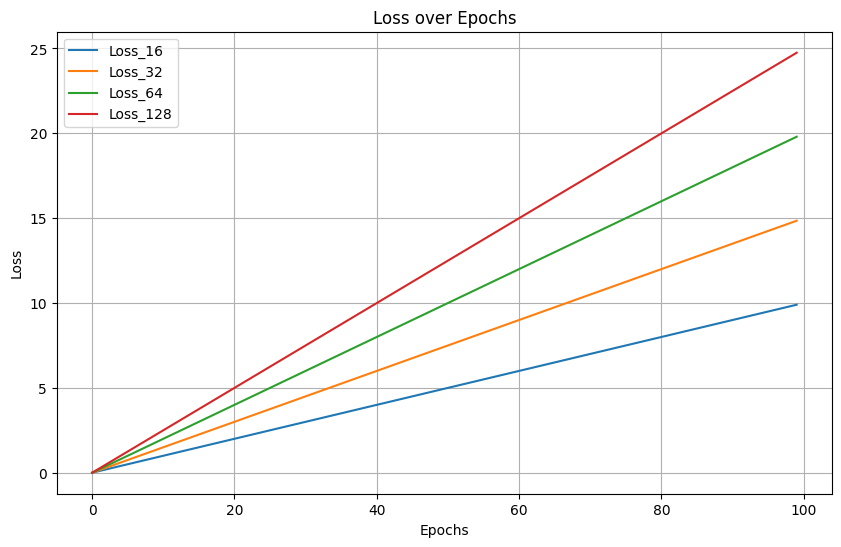

In [13]:
import numpy as np
import matplotlib.pyplot as plt

epochs = range(1, len(losses_16) + 1)

losses_16_np = [loss.item() for loss in losses_16]
losses_32_np = [loss.item() for loss in losses_32]
losses_64_np = [loss.item() for loss in losses_64]
losses_128_np = [loss.item() for loss in losses_128]

plt.figure(figsize=(10, 6))
plt.plot(epochs, losses_16_np, label='Loss_16')
plt.plot(epochs, losses_32_np, label='Loss_32')
plt.plot(epochs, losses_64_np, label='Loss_64')
plt.plot(epochs, losses_128_np, label='Loss_128')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.show()

In [18]:
import matplotlib.pyplot as plt

# 各エポックごとにロスをリストに追加する前にCPUに移動してスカラー値に変換
losses_64 = [loss.cpu().item() for loss in losses_64]
losses_128 = [loss.cpu().item() for loss in losses_128]
losses = [loss.cpu().item() for loss in losses]
V128_Loss = [loss.cpu().item() for loss in V128_Loss]

# ロスのリストが空でないことを確認
if len(losses_64) > 0 and len(losses_128) > 0 and len(losses) > 0:
    # エポック数に対応するx軸の値を作成
    epochs_range = range(1, epochs + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, losses_64, label='Loss_64')
    plt.plot(epochs_range, losses_128, label='Loss_128')
    plt.plot(epochs_range, losses, label='Total Loss')
    plt.plot(epochs_range, V128_Loss, label='Vector Loss (V64_128)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("ロスリストが空です。トレーニングが正しく行われたか確認してください。")



ロスリストが空です。トレーニングが正しく行われたか確認してください。


In [14]:
import matplotlib.pyplot as plt

# 各エポックごとにロスをリストに追加する前にCPUに移動してスカラー値に変換
# losses_64 = [loss.cpu().item() for loss in losses_64]
losses_128 = [loss.cpu().item() for loss in losses_128]
losses = [loss.cpu().item() for loss in losses]
V128_Loss = [loss.cpu().item() for loss in V128_Loss]

# ロスのリストが空でないことを確認
if len(losses_128) > 0 and len(losses) > 0:
    # エポック数に対応するx軸の値を作成
    epochs_range = range(1, epochs + 1)

    plt.figure(figsize=(10, 6))
    # plt.plot(epochs_range, losses_64, label='Loss_64')
    plt.plot(epochs_range, losses_128, label='Loss_128')
    plt.plot(epochs_range, losses, label='Total Loss')
    plt.plot(epochs_range, V128_Loss, label='Vector Loss (V64_128)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("ロスリストが空です。トレーニングが正しく行われたか確認してください。")

AttributeError: 'float' object has no attribute 'cpu'

In [14]:
CT1 = np.load('No6_CT1.npz')['Val']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2.npz')['Val']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

CT1_shape: (1, 128, 128, 128)
CT2_shape: (1, 128, 128, 128)


In [15]:
x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

torch.Size([2, 1, 128, 128, 128])
torch.Size([2, 1, 128, 128, 128])


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 学習済みモデルが既にある場合
model3D.load_state_dict(torch.load('model_VXM_3D_weights_V2222222222_omomi.pth', map_location=device))


# 検証データを使って予測を行う
model3D.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化
#     moving_images = moving_images
#     fixed_images = fixed_images

    moving_images = fixed_images11
    fixed_images = moving_images11

#     train_batch,_ = next(train_generator)
#     moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
#     fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)  
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    # source_16, target_16, moved_16_2, flow_field_16, source_32, moved_32, target_32, moved_32_2, flow_field_32,\
    # source_64,  moved_64, target_64, moved_64_2, flow_field_64, source_128, moved_128, target_128, moved_128_2, \
    # pos_flow, flow_field_all, moved_128_final= model3D(moving_images, fixed_images)

    # source_16, target_16, source_16_128, target_16_128, source_32, target_32, source_32_128, target_32_128, \
    # ource_64, target_64, source_64_128, target_64_128, \
    # source_128, target_128, moved_16_2, moved_32_2, moved_64_2, moved_128_2= model3D(moving_images, fixed_images)

    source_64, target_64, source_64_128, target_64_128, source_128, target_128, \
    moved_64_2, moved_128_2, flow_field_64, flow_field_64_256_resize,\
    flow_field_64_256_128_resize, flow_field = model3D(moving_images, fixed_images)
    

In [17]:
max_value2 = torch.max(flow_field).item()
print(max_value2)

0.007806857116520405


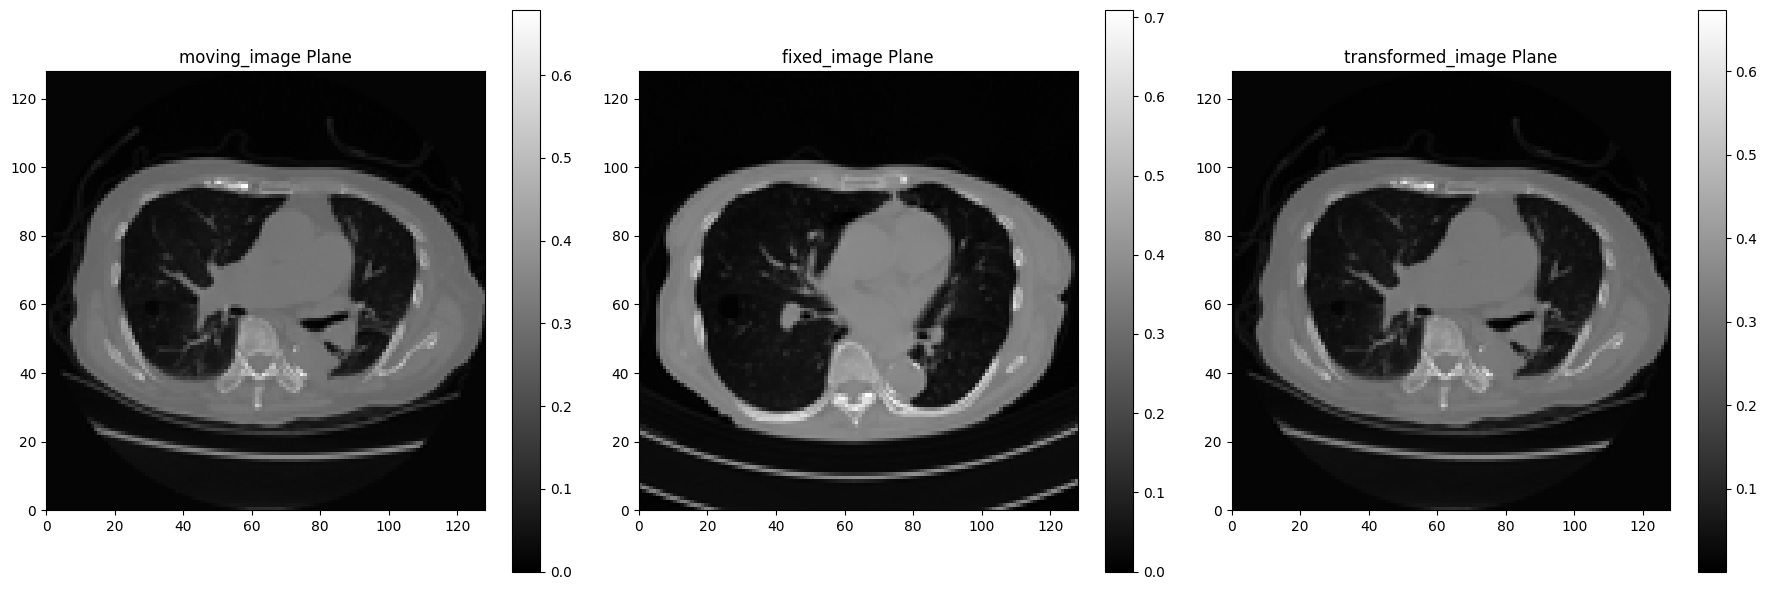

In [18]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

moving_image = source_128[0].cpu().numpy()
fixed_image = target_128[0].cpu().numpy()
transformed_image = moved_128_2[0].cpu().numpy()
# transformed_image = moved_128_2[0].detach().cpu().numpy()

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, 64, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, 64, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, 64, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [22]:
imsave('source_128V22222.tif', A)
imsave('target_128V22222.tif', B)
imsave('moved_128_2V22222.tif', C)

C:\Users\user\AppData\Local\Temp\ipykernel_21788\1575579918.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('source_128V22222.tif', A)
C:\Users\user\AppData\Local\Temp\ipykernel_21788\1575579918.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('target_128V22222.tif', B)
C:\Users\user\AppData\Local\Temp\ipykernel_21788\1575579918.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_128_2V22222.tif', C)


In [19]:
def dice_coefficient(img1, img2):
    intersection = np.logical_and(img1, img2)
    return 2.0 * intersection.sum() / (img1.sum() + img2.sum())

def jaccard_coefficient(img1, img2):
    intersection = np.logical_and(img1, img2)
    union = np.logical_or(img1, img2)
    return intersection.sum() / union.sum()

# 画像を2値化（任意のしきい値でしきい値処理を行う）
threshold = 0.3  # しきい値（任意の値を設定してください）
fixed_image_bin = (fixed_image > threshold).astype(int)
transformed_image_bin = (transformed_image > threshold).astype(int)

# Dice係数とJaccard係数を計算
dice = dice_coefficient(fixed_image_bin, transformed_image_bin)
print(f"Dice係数: {dice}")
jaccard = jaccard_coefficient(fixed_image_bin, transformed_image_bin)
print(f"Jaccard係数: {jaccard}")

Dice係数: 0.6599255641789432
Jaccard係数: 0.49245440890349507
